# Metric Estimation

## Imports

In [6]:
import matplotlib.pyplot as plt
import nltk
import pandas as pd
from nltk.corpus import stopwords
from wordcloud import WordCloud

from metrics.cohesion import cohesion_metric, get_cloud_word
from metrics.overlapping import overlapping_users

# Uncomment this line if you have to install stopwords
# nltk.download("stopwords")

## Global variables

In [2]:
comments_file = "./data/full_comments.csv"
social_cohesion_file = "./data/cohesion_vocabulary.csv"

comments_data = pd.read_csv(comments_file, index_col=0).reset_index(drop=True)
cohesion_vocab = list(pd.read_csv(social_cohesion_file, names=["word"])["word"])

stopwords = set(stopwords.words("english"))
for word in cohesion_vocab:
    if word in stopwords: stopwords.remove(word)

## Single Metrics

### Social Cohesion

In [3]:
cohesion_metric = cohesion_metric(comments_data, cohesion_vocab)

In [4]:
cohesion_metric

,cohesion_matches,total_words,cohesion_score
post_id,,,
100im14,357,5495.0,0.064968
1061zz6,428,6146.0,0.069639
1064tk5,683,10940.0,0.062431
106iwaf,112,1707.0,0.065612
1077n3v,879,13173.0,0.066727
...,...,...,...
ztzmmm,969,15338.0,0.063176
zum753,868,14542.0,0.059689
zxanwt,896,14330.0,0.062526


In [ ]:
cloud_word = get_cloud_word(comments_data, cohesion_vocab, stopwords)
cloud_word = pd.DataFrame(cloud_word)
agg_by_post = (
    cloud_word
    .groupby(["movie", "post_id", "word", "is_cohesion"])["frequency"]
    .sum()
)

cloud_word = agg_by_post.to_frame("frequency")
cloud_word.to_csv("./results/cloud_word.csv")

processing 137753 comments.
Successfully processed comment 5000.
Successfully processed comment 10000.
Successfully processed comment 15000.
Successfully processed comment 20000.
Successfully processed comment 25000.
Successfully processed comment 30000.
Successfully processed comment 35000.
Successfully processed comment 40000.
Successfully processed comment 45000.
Successfully processed comment 50000.
Successfully processed comment 55000.
Successfully processed comment 60000.
Successfully processed comment 65000.
Successfully processed comment 70000.
Successfully processed comment 75000.
Successfully processed comment 80000.
Successfully processed comment 85000.
Successfully processed comment 90000.
Successfully processed comment 95000.
Successfully processed comment 100000.
Successfully processed comment 105000.
Successfully processed comment 110000.
Successfully processed comment 115000.
Successfully processed comment 120000.
Successfully processed comment 125000.
Successfully proc

In [12]:
cloud_word = pd.read_csv("./results/cloud_word.csv")
cloud_word

,movie,post_id,word,is_cohesion,frequency
0,12th Fail,17ofzy5,12th,False,3
1,12th Fail,17ofzy5,14,False,1
2,12th Fail,17ofzy5,17ofzy5,False,2
3,12th Fail,17ofzy5,2,False,1
4,12th Fail,17ofzy5,3,False,1
...,...,...,...,...,...
807825,X,tb03wt,year,False,1
807826,X,tb03wt,yes,False,1
807827,X,tb03wt,yet,False,1
807828,X,tb03wt,young,False,1


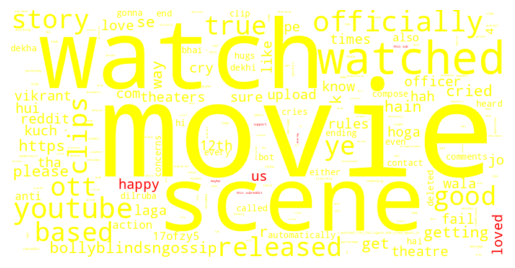

In [16]:
wc = WordCloud(
    background_color="white",
    width=800,
    height=400
)

movie = "12th Fail"
post_id = "17ofzy5"

subcloud = cloud_word[
    (cloud_word["movie"] == movie) &
    (cloud_word["post_id"] == post_id)
]

frequencies = dict(
    zip(subcloud["word"], subcloud["frequency"])
)

word_to_color = dict(
    zip(subcloud["word"], subcloud["is_cohesion"])
)

def cohesion_color_func(word, **kwargs):
    return "red" if word_to_color.get(word, True) else "yellow"

wc.generate_from_frequencies(frequencies)

plt.imshow(
    wc.recolor(color_func=cohesion_color_func),
    interpolation="bilinear"
)
plt.axis("off")
plt.show()

### Overlapping Users

In [5]:
overlapping_metric = overlapping_users(comments_data)

#### Example of result structure

In [7]:
films = list(overlapping_metric.keys())

i = 0
print(f"Overlappings for {films[i]}:")
print(overlapping_metric[films[i]])

Overlappings for 12th Fail:
                                               author_name  multiauthors
post_id                                                                 
17ofzy5  {hrishis, starryeyedgirll, Unlucky-Ad-6435, Au...             1
18wi8qw  {P1X3L5L4Y3R, wewake_235, AutoModerator, habib...             5
191nnek  {Fuzzy_Cup_1488, indianemployee, AkPakKarvepak...             3
193an4t  {Sanju-05, Nervous_Time_6480, Hallkbshjk, Auto...             3
1ldjpf3  {vbnty, karmazovMysskin, bitchimshanks, Techni...             2


## Metric Interaction

## Visualization